In [10]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict

In [11]:
class BatsmanState(TypedDict):
    # Inputs
    runs: int
    balls: int
    fours: int
    sixes: int
    # Computed outputs
    strike_rate: float
    bpb: float              # balls per boundary
    boundary_percent: float
    summary: str

In [12]:
def calculate_strike_rate(state: BatsmanState) -> dict:
    strike_rate = (state["runs"] / state["balls"]) * 100
    return {"strike_rate": round(strike_rate, 2)}

def calculate_bpb(state: BatsmanState) -> dict:
    # After how many balls does the batsman hit a boundary?
    bpb = state["balls"] / (state["fours"] + state["sixes"])
    return {"bpb": round(bpb, 2)}

def calculate_boundary_percent(state: BatsmanState) -> dict:
    runs_in_boundaries = (state["fours"] * 4) + (state["sixes"] * 6)
    boundary_percent = (runs_in_boundaries / state["runs"]) * 100
    return {"boundary_percent": round(boundary_percent, 2)}

def summary(state: BatsmanState) -> dict:
    summary_text = (
        f"Strike Rate: {state['strike_rate']}\n"
        f"Balls Per Boundary: {state['bpb']}\n"
        f"Boundary Percentage: {state['boundary_percent']}%"
    )
    return {"summary": summary_text}

In [13]:
graph = StateGraph(BatsmanState)

graph.add_node('calculate_strike_rate', calculate_strike_rate)
graph.add_node('calculate_bpb', calculate_bpb)
graph.add_node('calculate_boundary_percent', calculate_boundary_percent)
graph.add_node('summary', summary)

graph.add_edge(START, 'calculate_strike_rate')
graph.add_edge(START, 'calculate_bpb')
graph.add_edge(START, 'calculate_boundary_percent')

graph.add_edge('calculate_strike_rate', 'summary')
graph.add_edge('calculate_bpb', 'summary')
graph.add_edge('calculate_boundary_percent', 'summary')

graph.add_edge('summary', END)

workflow = graph.compile()

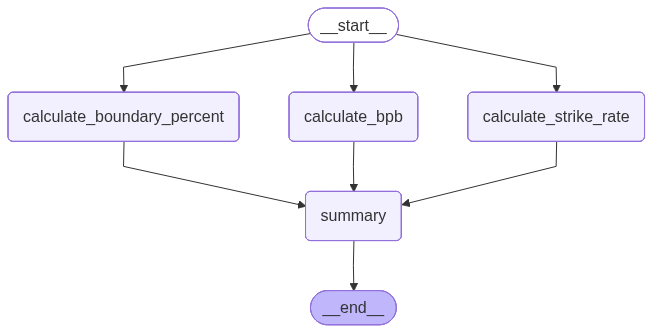

In [14]:
graph.compile()

In [15]:
# Run
initial_state = {"runs": 100, "balls": 50, "fours": 6, "sixes": 4}
final_state = workflow.invoke(initial_state)
print(final_state)

{'runs': 100, 'balls': 50, 'fours': 6, 'sixes': 4, 'strike_rate': 200.0, 'bpb': 5.0, 'boundary_percent': 48.0, 'summary': 'Strike Rate: 200.0\nBalls Per Boundary: 5.0\nBoundary Percentage: 48.0%'}
